# Note

Here we evaluate the distribtuion and semantic correctness over common feasible solutions of CVX
That said demoniator for % will be: N - N_unfeas_ws_cvx

In [1]:
import os
import sys
import numpy as np 
from pathlib import Path
# Get the root folder (two levels up from this file)
root_folder = Path.cwd().parent

# Add to sys.path
sys.path.append(str(root_folder))

from importlib.machinery import SourceFileLoader
import matplotlib.pyplot as plt
import json 
from pathlib import Path
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D
from collections import defaultdict
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from optimization import ff_scenario as ff  # wherever ff lives
from optimization.ff_scenario import obs, robot_radius, table  # must exist in your repo
from dynamics.freeflyer import FreeflyerModel, ocp_no_obstacle_avoidance, ocp_obstacle_avoidance, ocp_obstacle_avoidance_feasibility, compute_constraint_to_go, sample_init_target

In [2]:

ws_version = 'v_06_80k_unseen' #'v_01_total'  # warmstarting analysis version 'v_01_total_seen_xxxxxxxxx'. 'v_01_total_seen_fo'. 'v_06_total_unseen'
npz_path=Path(root_folder) / "optimization" / "saved_files" / "warmstarting" / f"ws_analysis_{ws_version}.npz"
raw = np.load(npz_path, allow_pickle=True)
CASE_NAMES = [
    "left_fast",   # 0
    "left_slow",   # 1
    "right_fast",  # 2
    "right_slow",  # 3
    "direct_fast", # 4
    "direct_slow"  # 5
]

# --- Load and inspect ---
N = len(raw["behavior"])
print(f"Loaded {N} trajectories")
behavior = np.asarray(raw["behavior"]).reshape(-1)
print(f"Loaded before filtering {len(behavior)} samples from {npz_path.name}\n")

# --- Print unique behaviors and their counts ---
unique_behaviors, counts = np.unique(behavior, return_counts=True)
for b, c in zip(unique_behaviors, counts):
    print(f"Behavior {int(b):>2d}: {c:>5d} trajectories")

i_unfeas_cvx = raw['i_unfeas_cvx']
i_unfeas_cvx_scp = raw['i_unfeas_scp_cvx']
i_unfeas_DT_ctg = raw['i_unfeas_DT_ctg']
print('cvx infeasible indexes: ', raw['i_unfeas_cvx'])
print('scp cvx infeasible indexes: ', raw['i_unfeas_scp_cvx'])
print('DT infeasible indexes: ', raw['i_unfeas_DT_ctg'])
print('DT infeasible indexes: ', raw['i_unfeas_DT_ctg_op'])

i_unfeas_total = set(i_unfeas_cvx).union(set(i_unfeas_cvx_scp)).union(set(i_unfeas_DT_ctg))
print(i_unfeas_total)

Loaded 1000 trajectories
Loaded before filtering 1000 samples from ws_analysis_v_06_80k_unseen.npz

Behavior  0:   146 trajectories
Behavior  1:   183 trajectories
Behavior  2:   147 trajectories
Behavior  3:   173 trajectories
Behavior  4:   175 trajectories
Behavior  5:   176 trajectories
cvx infeasible indexes:  [165 234 304 359 531 625 803 948 998]
scp cvx infeasible indexes:  [  3  23  27 142 165 176 191 224 234 275 299 304 315 359 377 442 472 478
 491 531 564 578 625 658 673 679 717 719 769 790 803 807 810 814 822 948
 976 998]
DT infeasible indexes:  [  3 216 769 883 912]
DT infeasible indexes:  [  3 216 769 883 912]
{769, 3, 142, 912, 658, 531, 275, 790, 23, 27, 673, 803, 165, 679, 807, 810, 299, 814, 304, 176, 948, 564, 822, 442, 315, 191, 578, 717, 719, 976, 472, 216, 478, 224, 998, 359, 234, 491, 625, 883, 377}


In [3]:
# mask out all infeasible samples from the data

# Convert to dict for easy editing
data_t = {k: raw[k] for k in raw.files}
# -------------------------
# Build the infeasible index union
# -------------------------
i_unfeas_cvx     = np.asarray(data_t["i_unfeas_cvx"], dtype=int)
i_unfeas_scp_cvx = np.asarray(data_t["i_unfeas_scp_cvx"], dtype=int)
i_unfeas_DT_ctg  = np.asarray(data_t["i_unfeas_DT_ctg"], dtype=int)

# Union set
# i_unfeas_total = set(i_unfeas_cvx) | set(i_unfeas_DT_ctg)
i_unfeas_total = set(i_unfeas_cvx)
i_unfeas_total = np.array(sorted(list(i_unfeas_total)), dtype=int)

print(f"Total infeasible samples: {len(i_unfeas_total)}")
print(f"Infeasible indices: {i_unfeas_total.tolist()}")

# -------------------------
# Create mask of feasible samples
# -------------------------
N = len(data_t["behavior"])
mask = np.ones(N, dtype=bool)
mask[i_unfeas_total] = False

print(f"Total feasible samples: {mask.sum()} / {N}")

# -------------------------
# Filter all arrays whose first dim = N
# -------------------------
data = {}
for key, value in data_t.items():
    arr = np.asarray(value)
    if arr.ndim >= 1 and arr.shape[0] == N:
        data[key] = arr[mask]
    else:
        data[key] = arr  # keep metadata arrays unchanged

print("\nCleaned dataset created: data")


Total infeasible samples: 9
Infeasible indices: [165, 234, 304, 359, 531, 625, 803, 948, 998]
Total feasible samples: 991 / 1000

Cleaned dataset created: data


In [4]:

def _as_batch(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[0] == 6:
        return arr[None, ...]  # (6, T) -> (1, 6, T)
    return arr


# data = data_dt
states = _as_batch(data["states_ws_DT_ctg"])             # (N, 6, T)
# states = _as_batch(data["states_scp_DT_ctg_op"])         # (N, 6, T)

# data = data_cvx
# states = _as_batch(data["states_cvx"])                   # (N, 6, T)
# states = _as_batch(data["states_scp_cvx"])               # (N, 6, T)





In [5]:
def _plot_environment(ax):
    """Draws the static environment on a given matplotlib Axes."""
    # Table
    ax.add_patch(Rectangle((table['xy_low'][0], table['xy_low'][1]),
                           table['xy_up'][0] - table['xy_low'][0],
                           table['xy_up'][1] - table['xy_low'][1],
                           fc=(0.5, 0.5, 0.5, 0.15), ec='k', label='table', zorder=2.5))

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = 'Obstacle' 
        lab3 = 'L/R Body' if n== 0 else None
        lab2 = 'robot radius' if n==0 else None
        if n == 1:
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n],
                            fc='r', ec='none', label=lab1, zorder=2.6))
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n] + robot_radius,
                            fc='grey', alpha=0.2, ec='none', label=lab2, zorder=2.6))
        else:
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n],
                            fc='g', ec='none', label=lab3, zorder=2.6))
            ax.add_patch(Circle(obs['position'][n, :], obs['radius'][n] + robot_radius,
                            fc='grey', alpha=0.2, ec='none', label=lab2, zorder=2.6))
            
       

    # Common formatting
    ax.set_aspect('equal')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.grid(True, alpha=0.3)


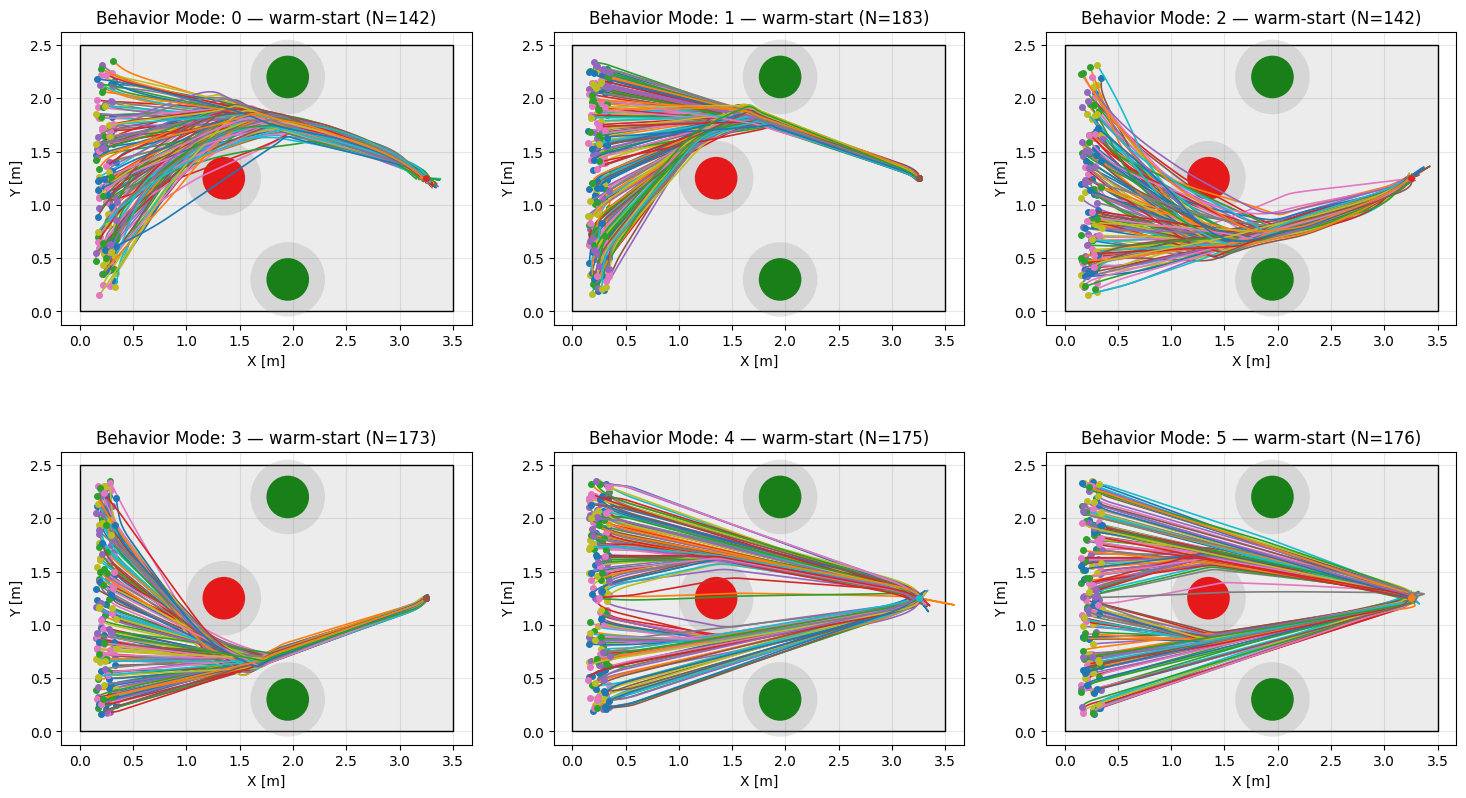

In [6]:


behavior     = np.asarray(data["behavior"]).reshape(-1)    # (N,)
n_behaviors = 6
state_init   = data.get("state_init", None)
state_final  = data.get("state_final", None)

N, D, T = states.shape

# Figure + axes
fig, axes = plt.subplots(2, 3, figsize=(18,10), constrained_layout=False)
axes = axes.ravel()

# Consistent axes limits (use table bounds if available)
x_lo, y_lo = table['xy_low']
x_hi, y_hi = table['xy_up']
x_margin = 0.05 * (x_hi - x_lo)
y_margin = 0.05 * (y_hi - y_lo)
xlim = (x_lo - x_margin, x_hi + x_margin)
ylim = (y_lo - y_margin, y_hi + y_margin)

# To build a single legend later
env_handles, env_labels = None, None
any_traj = False

for b in range(n_behaviors):
    ax = axes[b]
    _plot_environment(ax)
    ax.set_aspect('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    title = f"Behavior Mode: {b}"
    idx = np.where(behavior == b)[0]
    ax.set_title(f"{title} — warm-start (N={len(idx)})")

    # Save env handles/labels once
    if env_handles is None:
        env_handles, env_labels = ax.get_legend_handles_labels()

    # Plot trajectories
    if len(idx) > 0:
        any_traj = True
        for k in idx:
            xy = states[k, :2, :]  # (2, T)
            ax.plot(xy[0, :], xy[1, :], linewidth=1.2, zorder=3)
            if state_init is not None:
                ax.scatter(state_init[k, 0], state_init[k, 1], s=16, zorder=3)
            if state_final is not None:
                ax.scatter(state_final[k, 0], state_final[k, 1], s=16, zorder=3)
    ax.grid(True, alpha=0.3)

# If fewer than 6 behaviors, blank remaining axes
for b in range(n_behaviors, 6):
    fig.delaxes(axes[b])

plt.show()



In [7]:

# ---------------------------------------------------------
# Compute first timestep entering tolerance region per behavior mode
# ---------------------------------------------------------

tol = 0.09      # 9 cm tolerance
n_behaviors = 6

final_xy_all = state_final[:, :]   # (N, 2)

print("\n================ Goal Reach Tim Step Statistics (per Behavior) ================\n")

for b in range(n_behaviors):

    idx_b = np.where(behavior == b)[0]
    if idx_b.size == 0:
        print(f"Behavior {b}: No trajectories.")
        continue

    reach_times = []

    for k in idx_b:
        traj_xy = states[k, :, :].T     # (T,2)
        goal_xy = final_xy_all[k]        # (2,)

        dist = np.linalg.norm(traj_xy - goal_xy, axis=1)
        idx_reach = np.where(dist < tol)[0]   # all timesteps within tolerance

        if len(idx_reach) > 0:
            reach_times.append(idx_reach[0])  # first reach
        else:
            reach_times.append(None)  # never reached

    # Keep only valid reach times
    valid = [t for t in reach_times if t is not None]

    print(f"Behavior {b}: N = {len(idx_b)}")
    if len(valid) > 0:
        print(f"  ✓ Min reach timestep : {min(valid)}")
        print(f"  ✓ Max reach timestep : {max(valid)}")
        print(f"  ✓ Mean reach timestep: {np.mean(valid):.2f}")
        print(f"  ✓ Reached goal region: {len(valid)} / {len(idx_b)}")
    else:
        print("  ✗ No trajectories reached tolerance region.")

    print()



================ Goal Reach Tim Step Statistics (per Behavior) ================

Behavior 0: N = 142
  ✓ Min reach timestep : 60
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 70.52
  ✓ Reached goal region: 142 / 142

Behavior 1: N = 183
  ✓ Min reach timestep : 94
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 95.38
  ✓ Reached goal region: 183 / 183

Behavior 2: N = 142
  ✓ Min reach timestep : 60
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 70.57
  ✓ Reached goal region: 142 / 142

Behavior 3: N = 173
  ✓ Min reach timestep : 94
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 95.62
  ✓ Reached goal region: 173 / 173

Behavior 4: N = 175
  ✓ Min reach timestep : 58
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 65.47
  ✓ Reached goal region: 175 / 175

Behavior 5: N = 176
  ✓ Min reach timestep : 92
  ✓ Max reach timestep : 100
  ✓ Mean reach timestep: 95.11
  ✓ Reached goal region: 176 / 176



Total trajectories that never reached tolerance: 0 / 991
Failing trajectories (index, behavior, full XY trajectory):


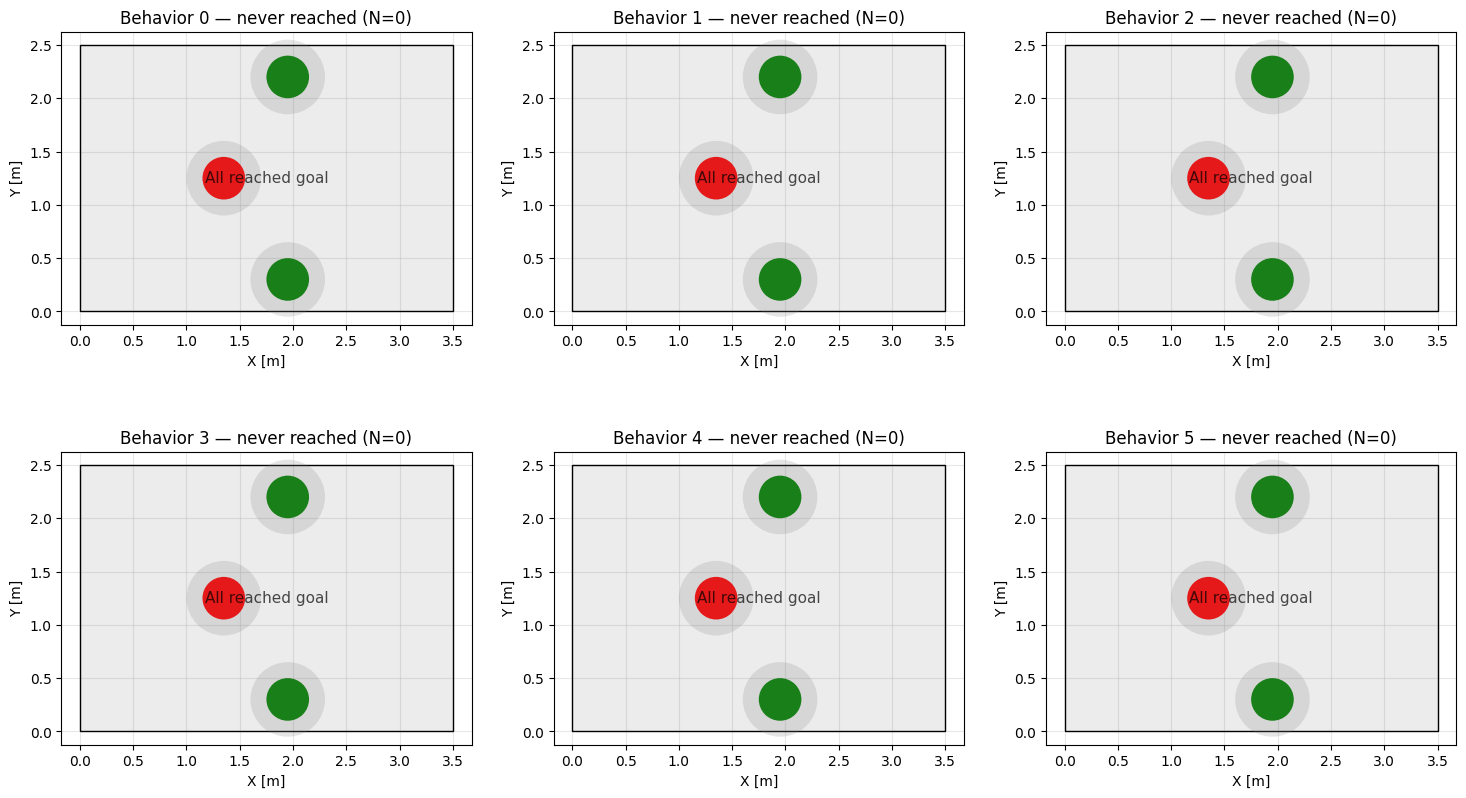

In [8]:
tol = 0.06  # 9 cm tolerance

never_reach = np.zeros(N, dtype=bool)   # True if traj never enters tol region
final_xy_all = state_final[:, :2]       # (N, 2)

for k in range(N):
    traj_xy = states[k, :2, :].T        # (T, 2)
    goal_xy = final_xy_all[k]           # (2,)

    # distance to goal at all timesteps
    dist = np.linalg.norm(traj_xy - goal_xy, axis=1)

    # handle NaNs: if everything is NaN, treat as never reaching
    if not np.any(np.isfinite(dist)):
        never_reach[k] = True
        continue

    idx_reach = np.where(dist < tol)[0]

    if len(idx_reach) == 0:
        never_reach[k] = True

fail_idxs = np.where(never_reach)[0]
print("====================================================")
print(f"Total trajectories that never reached tolerance: {len(fail_idxs)} / {N}")
print("Failing trajectories (index, behavior, full XY trajectory):")

for k in fail_idxs:
    beh = behavior[k]
    traj_xy = states[k, :2, :].T   # shape (T,2)

    print(f"\n----------------------------------------------------")
    print(f"Trajectory {k} | behavior {beh}")
    print("Full XY trajectory:")

    for t, (x, y) in enumerate(traj_xy):
        print(f"   t={t:3d}  (x={x:.4f},  y={y:.4f})")

print("====================================================")

# ---------- Plot only the "never reached goal" trajectories -------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=False)
axes2 = axes2.ravel()

# Consistent axes limits
x_lo, y_lo = table['xy_low']
x_hi, y_hi = table['xy_up']
x_margin = 0.05 * (x_hi - x_lo)
y_margin = 0.05 * (y_hi - y_lo)
xlim = (x_lo - x_margin, x_hi + x_margin)
ylim = (y_lo - y_margin, y_hi + y_margin)

for b in range(n_behaviors):
    ax = axes2[b]
    _plot_environment(ax)
    ax.set_aspect('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")

    # trajectories of this behavior that failed
    idx_b_fail = [k for k in fail_idxs if behavior[k] == b]

    ax.set_title(f"Behavior {b} — never reached (N={len(idx_b_fail)})")

    if len(idx_b_fail) == 0:
        ax.text(0.5, 0.5, "All reached goal",
                ha="center", va="center",
                transform=ax.transAxes, fontsize=11, alpha=0.7)
        ax.grid(True, alpha=0.3)
        continue

    for k in idx_b_fail:
        xy = states[k, :2, :]   # (2, T)

        # skip if completely NaN
        if not np.any(np.isfinite(xy)):
            ax.text(0.5, 0.1, f"traj {k}: NaN",
                    ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="red")
            continue

        ax.plot(xy[0, :], xy[1, :],
                linewidth=1.8,
                color="crimson",
                alpha=0.9,
                zorder=4)

        # Mark the associated goal position
        gx, gy = final_xy_all[k]
        ax.scatter(gx, gy, s=35, marker='x', c='k', zorder=5)

    ax.grid(True, alpha=0.3)

# Clean up extra axes if needed
for b in range(n_behaviors, 6):
    fig2.delaxes(axes2[b])

plt.show()


# Actions Norm

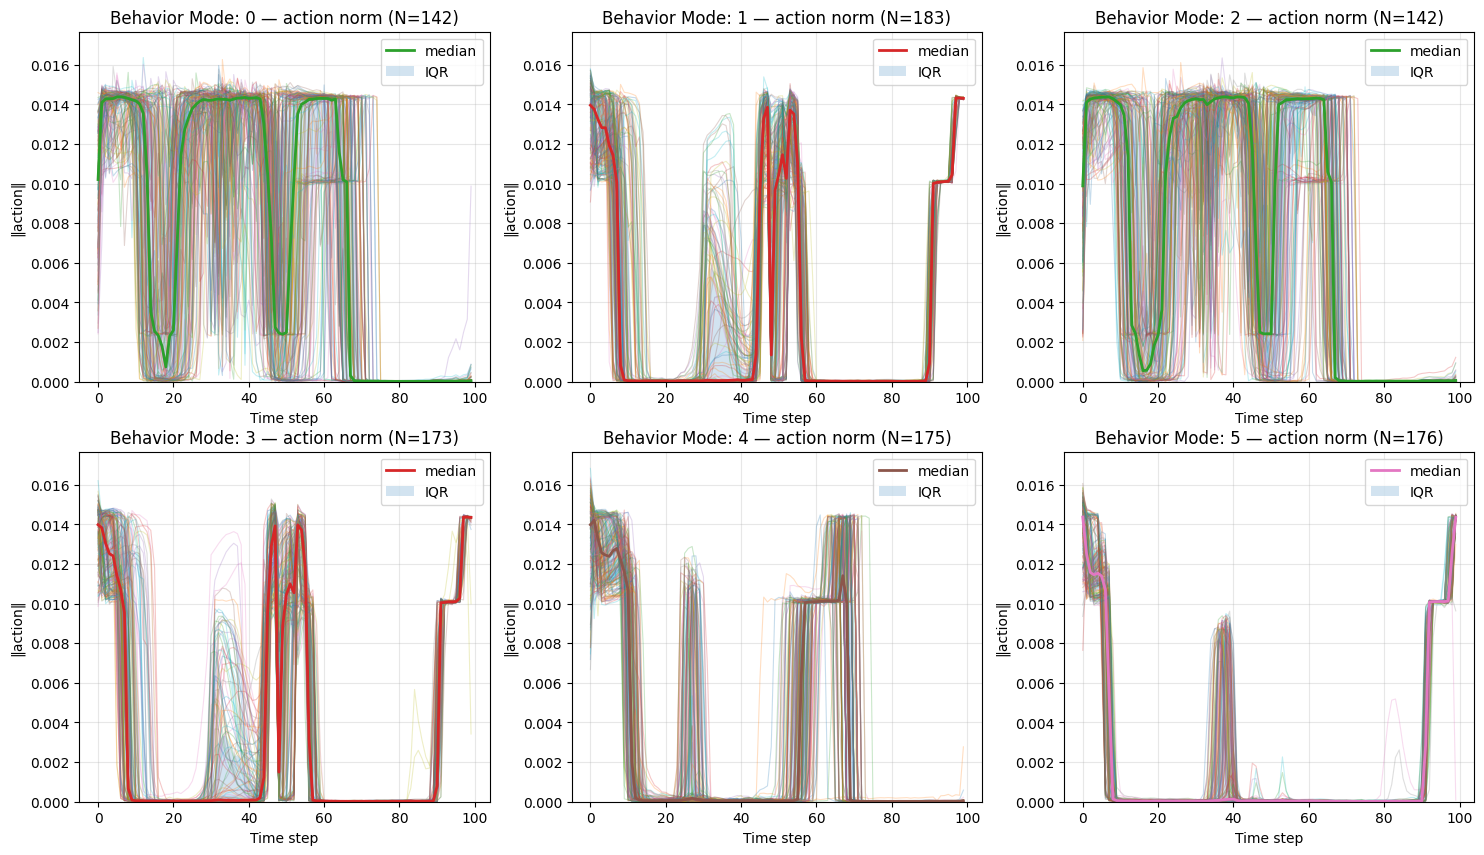

In [9]:
"""
One big figure with 6 subplots (2x3). For each behavior b, plots the L2 norm
of action (||a_t||) across time for all DT warm-start trajectories in that mode.

- Light lines = individual trajectories in that behavior
- Bold line   = median across trajectories (if aggregate=True)
- Shaded band = 25–75 percentile (if aggregate=True)
"""

# actions = np.asarray(data["actions_cvx"])          # (N, 3, T)
# actions = np.asarray(data_cvx["actions_scp_cvx"])          # (N, 3, T)



actions = np.asarray(data["actions_ws_DT_ctg"])          # (N, 3, T)
# actions = np.asarray(data["actions_scp_DT_ctg"])          # (N, 3, T)


# actions = np.asarray(data["actions_ws_DT_ctg"])          # (N, 3, T)
# actions = np.asarray(data["actions_scp_DT_ctg_op"])          # (N, 3, T)



behavior      = np.asarray(data["behavior"]).reshape(-1)   # (N,)

N, A, T = actions.shape
t = np.arange(T) 
act_norms = np.linalg.norm(actions, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(18,10), constrained_layout=False)
axes = axes.ravel()

y_max = 0.0  # for consistent y-limits across subplots

for b in range(n_behaviors):
    ax = axes[b]
    idx = np.where(behavior == b)[0]
    title = f"Behavior Mode: {b}"
    ax.set_title(f"{title} — action norm (N={len(idx)})")

    if len(idx) > 0:
        # Plot each trajectory lightly
        for k in idx:
            y = act_norms[k]          # (T,)
            ax.plot(t, y, linewidth=0.8, alpha=0.25)
            y_max = max(y_max, float(np.max(y)))

        
        Y = act_norms[idx]        # (n_b, T)
        med = np.median(Y, axis=0)
        q25 = np.percentile(Y, 25, axis=0)
        q75 = np.percentile(Y, 75, axis=0)
        ax.plot(t, med, linewidth=2.0, label="median")
        ax.fill_between(t, q25, q75, alpha=0.2, label="IQR")
        y_max = max(y_max, float(np.max(q75)))
    else:
        ax.text(0.5, 0.5, "no trajectories", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlabel("Time step")
    ax.set_ylabel("‖action‖")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

# If fewer than 6 behaviors, remove extras
for b in range(n_behaviors, 6):
    fig.delaxes(axes[b])

# Harmonize y-limits (nice headroom)
if y_max > 0:
    for b in range(min(n_behaviors, 6)):
        axes[b].set_ylim(0, y_max * 1.05)

# State to goals Norm

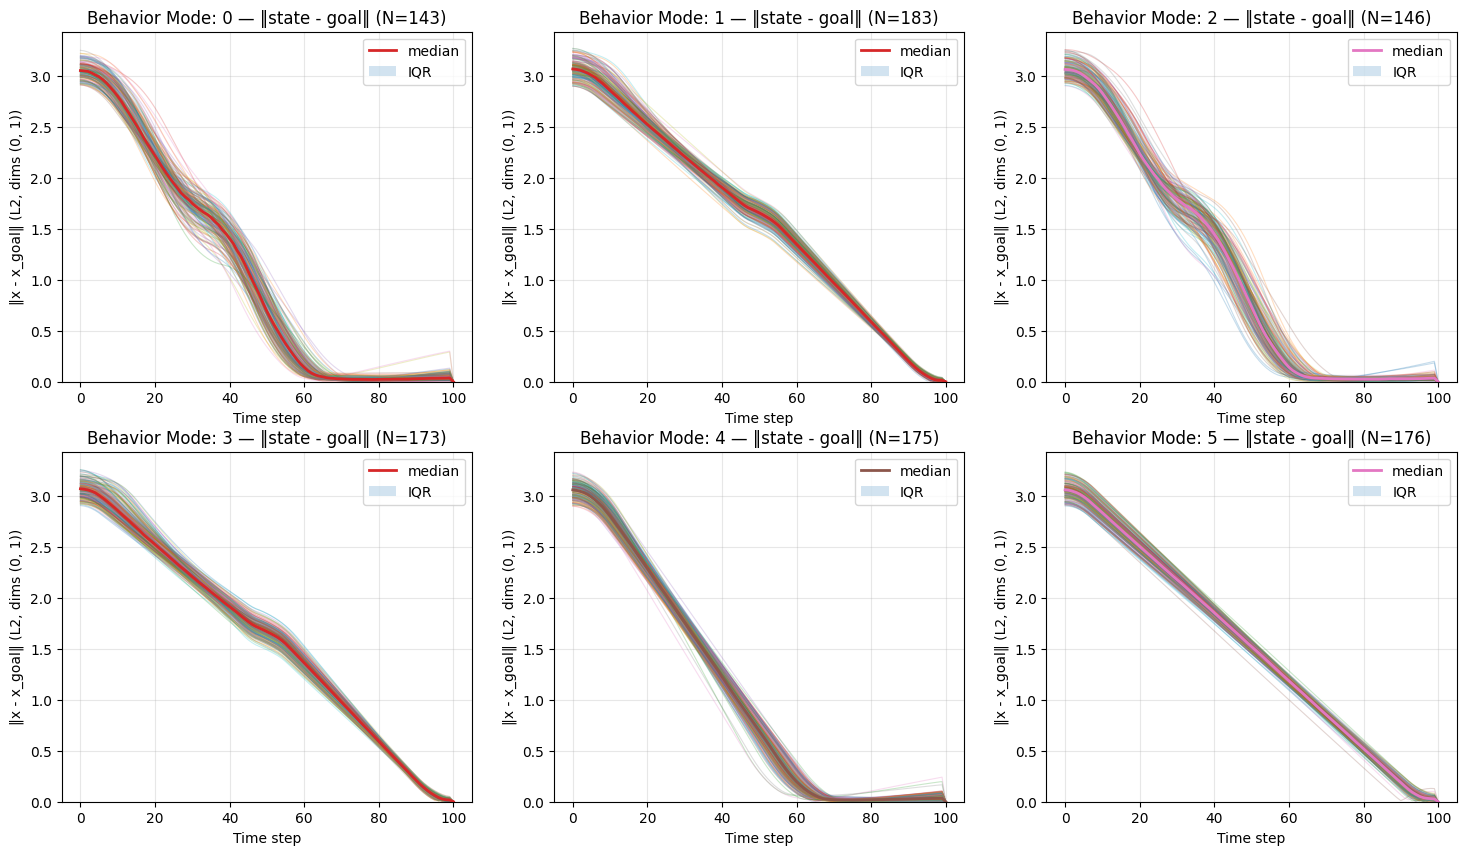

In [36]:

state_target = np.array([ (ff.goal_region['xy_low'][0] + ff.goal_region['xy_up'][0])/2,
                                  (ff.goal_region['xy_low'][1] + ff.goal_region['xy_up'][1])/2,
                                  0.0,
                                  0.0,
                                  0.0,
                                  0.0])



states = _as_batch(data["states_ws_DT_ctg"])             # (N, 6, T)
# states = _as_batch(data["states_scp_DT_ctg"])         # (N, 6, T)

# data = data_dt_op
# states = _as_batch(data["states_ws_DT_ctg"])             # (N, 6, T)
# states = _as_batch(data["states_scp_DT_ctg_op"])         # (N, 6, T)

# data = data_cvx
# states = _as_batch(data["states_cvx"])                   # (N, 6, T)
# states = _as_batch(data["states_scp_cvx"])               # (N, 6, T)

behavior     = np.asarray(data["behavior"]).reshape(-1)   # (N,)
dims = (0,1) # x,y
# dims = None # all
norm_ord = 2
N, D, T = states.shape

# choose dims
if dims is None:
    dims = tuple(range(D))
else:
    dims = tuple(dims)


t = np.arange(T)
goal = np.asarray(state_target).reshape(D, 1)

# restrict dims
X = states[:, dims, :]                         # (N, d, T)
G = goal[dims, :]                              # (d, 1)

# compute norm across selected dims
if norm_ord == 1:
    state_err = np.sum(np.abs(X - G), axis=1)          # (N, T)
elif norm_ord == 2:
    state_err = np.linalg.norm(X - G, axis=1)          # (N, T)
elif norm_ord == np.inf:
    state_err = np.max(np.abs(X - G), axis=1)          # (N, T)
else:
    # general p-norm: ||v||_p = (sum |v|^p)^(1/p)
    p = float(norm_ord)
    state_err = np.power(np.sum(np.abs(X - G) ** p, axis=1), 1.0 / p)

fig, axes = plt.subplots(2, 3, figsize=(18,10), constrained_layout=False)
axes = axes.ravel()

y_max = 0.0

for b in range(n_behaviors):
    ax = axes[b]
    idx = np.where(behavior == b)[0]
    title = f"Behavior Mode: {b}"
    ax.set_title(f"{title} — ‖state - goal‖ (N={len(idx)})")

    if len(idx) > 0:
        # plot all trajectories lightly
        for k in idx:
            y = state_err[k]    # (T,)
            ax.plot(t, y, linewidth=0.8, alpha=0.25)
            y_max = max(y_max, float(np.max(y)))

        Y = state_err[idx]          # (n_b, T)
        med = np.median(Y, axis=0)
        q25 = np.percentile(Y, 25, axis=0)
        q75 = np.percentile(Y, 75, axis=0)
        ax.plot(t, med, linewidth=2.0, label="median")
        ax.fill_between(t, q25, q75, alpha=0.2, label="IQR")
        y_max = max(y_max, float(np.max(q75)))
    else:
        ax.text(0.5, 0.5, "no trajectories", ha="center", va="center", transform=ax.transAxes)

    # labels reflect norm & dims used
    dim_str = "all dims" if len(dims) == D else f"dims {dims}"
    ord_str = {1: "L1", 2: "L2"}.get(norm_ord, f"L{norm_ord}")
    ax.set_xlabel("Time step")
    ax.set_ylabel(f"‖x - x_goal‖ ({ord_str}, {dim_str})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

# remove extras if <6
for b in range(n_behaviors, 6):
    fig.delaxes(axes[b])

if y_max > 0:
    for b in range(min(n_behaviors, 6)):
        axes[b].set_ylim(0, y_max * 1.05)


# Combined WS analysis

## Warmstart Solution

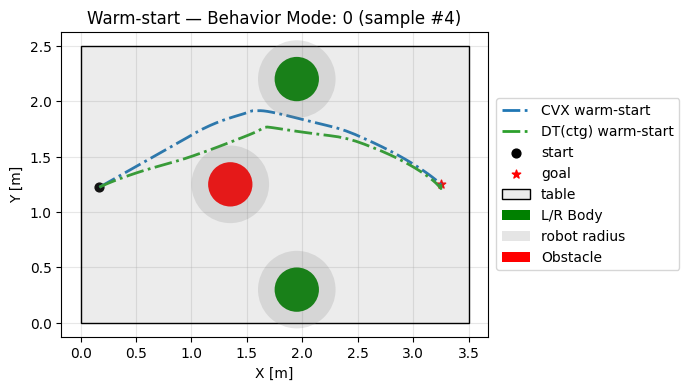

In [10]:
def load_ws_npz(npz_path: Path):
    states_cvx        = _as_batch(data.get("states_cvx", None))
    states_ws_DT_ctg  = _as_batch(data.get("states_ws_DT_ctg", None))
    if states_cvx is None and states_ws_DT_ctg is None:
        raise ValueError("No warm-start arrays found in the npz.")
    
    behavior    = np.asarray(data["behavior"]).reshape(-1)
    state_init  = data.get("state_init", None)
    state_final = data.get("state_final", None)

    # Infer shape
    ref = next(a for a in (states_cvx, states_ws_DT_ctg) if a is not None)
    N, D, T = ref.shape
    if state_init is not None:
        state_init = np.broadcast_to(np.asarray(state_init).reshape(-1, D), (N, D))
    if state_final is not None:
        state_final = np.broadcast_to(np.asarray(state_final).reshape(-1, D), (N, D))

    return dict(
        states_cvx=states_cvx,
        states_ws_DT_ctg=states_ws_DT_ctg,
        behavior=behavior,
        state_init=state_init,
        state_final=state_final,
        N=N, D=D, T=T
    )

def find_sample_with_all_three(ws, prefer_index: int | None = None, behavior_id: int | None = None):
    """Return index of sample that has all three trajectories (finite data)."""
    A, C = ws["states_cvx"], ws["states_ws_DT_ctg"]
    N = ws["N"]

    def good(arr, k): return arr is not None and k < arr.shape[0] and np.isfinite(arr[k]).all()
    def valid(k): return good(A, k) and good(C, k)

    if prefer_index is not None:
        if 0 <= prefer_index < N and valid(prefer_index):
            return prefer_index
        raise ValueError(f"Sample {prefer_index} missing data or out of range.")

    idxs = np.arange(N)
    if behavior_id is not None:
        idxs = idxs[ws["behavior"] == behavior_id]
    for k in idxs:
        if valid(k):
            return k
    raise ValueError("No sample found with all three solutions present.")

def plot_single_sample_overlay(ws, sample_index: int, figsize=(7, 7), show_start_goal=True, title_prefix=""):
    """Plot one sample’s three warm-start trajectories with legend on the right."""
    k = sample_index
    A = ws["states_cvx"][k]
    C = ws["states_ws_DT_ctg"][k]

    # Axis limits from environment
    x_lo, y_lo = table['xy_low']
    x_hi, y_hi = table['xy_up']
    margin_x = 0.05 * (x_hi - x_lo)
    margin_y = 0.05 * (y_hi - y_lo)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_environment(ax)
    ax.set_aspect("equal")
    ax.set_xlim(x_lo - margin_x, x_hi + margin_x)
    ax.set_ylim(y_lo - margin_y, y_hi + margin_y)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")

    b = int(ws["behavior"][k])
    title = f"Behavior Mode: {b}"
    ax.set_title(f"{title_prefix} — {title} (sample #{k})" if title_prefix else f"{title} (sample #{k})")

    # Plot trajectories
    styles = [
        ("CVX warm-start", A, dict(linestyle="-.",  linewidth=2.0, color="tab:blue")),
        ("DT(ctg) warm-start",  C, dict(linestyle="-.", linewidth=2.0, color="tab:green")),
    ]
    handles, labels = [], []
    for label, arr, style in styles:
        xy = arr[:2, :]
        h, = ax.plot(xy[0], xy[1], **style)
        handles.append(h)
        labels.append(label)

    # Start/goal markers
    if show_start_goal:
        if ws["state_init"] is not None:
            h0 = ax.scatter(ws["state_init"][k, 0], ws["state_init"][k, 1], s=40, c="k", marker="o")
            handles.append(h0); labels.append("start")
        if ws["state_final"] is not None:
            h1 = ax.scatter(ws["state_final"][k, 0], ws["state_final"][k, 1], s=40, c="r", marker="*")
            handles.append(h1); labels.append("goal")

    # Add environment legend items once
    env_h, env_l = ax.get_legend_handles_labels()
    handles += env_h
    labels  += env_l

    ax.grid(True, alpha=0.3)

    # Legend docked on the right (outside plot)
    fig.subplots_adjust(right=0.78)
    ax.legend(handles, labels,
              loc="center left", bbox_to_anchor=(1.02, 0.5),
              frameon=True, borderaxespad=0.0)

    plt.tight_layout()
    plt.show()

ws = load_ws_npz(npz_path)
k = find_sample_with_all_three(ws, prefer_index=4, behavior_id=0)  # or set prefer_index/behavior_id
plot_single_sample_overlay(ws, k, figsize=(7,7), title_prefix="Warm-start")


# SCP Solution

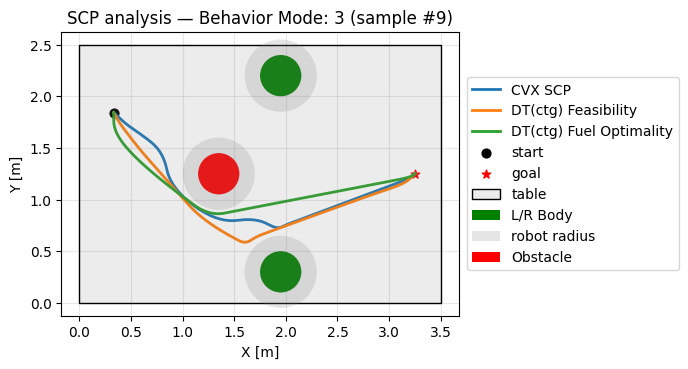

In [11]:

def load_ws_npz(npz_path: Path):
    """Load warm-start .npz and return dict with normalized arrays + metadata."""
    states_scp_cvx        = _as_batch(data.get("states_scp_cvx", None))
    states_scp_DT_ctg  = _as_batch(data.get("states_scp_DT_ctg", None))
    states_scp_DT_ctg_op  = _as_batch(data.get("states_scp_DT_ctg_op", None))

    if states_scp_cvx is None and states_scp_DT_ctg is None and states_scp_DT_ctg_op is None:
        raise ValueError("No warm-start arrays found in the npz.")
    
    behavior    = np.asarray(data["behavior"]).reshape(-1)
    state_init  = data.get("state_init", None)
    state_final = data.get("state_final", None)

    # Infer shape
    ref = next(a for a in (states_scp_cvx, states_scp_DT_ctg, states_scp_DT_ctg_op) if a is not None)
    N, D, T = ref.shape
    if state_init is not None:
        state_init = np.broadcast_to(np.asarray(state_init).reshape(-1, D), (N, D))
    if state_final is not None:
        state_final = np.broadcast_to(np.asarray(state_final).reshape(-1, D), (N, D))

    return dict(
        states_scp_cvx=states_scp_cvx,
        states_scp_DT_ctg=states_scp_DT_ctg,
        states_scp_DT_ctg_op=states_scp_DT_ctg_op,
        behavior=behavior,
        state_init=state_init,
        state_final=state_final,
        N=N, D=D, T=T
    )

def find_sample_with_all_three(ws, prefer_index: int | None = None, behavior_id: int | None = None):
    """Return index of sample that has all three trajectories (finite data)."""
    A, B, C = ws["states_scp_cvx"], ws["states_scp_DT_ctg"], ws["states_scp_DT_ctg_op"]
    N = ws["N"]

    def good(arr, k): return arr is not None and k < arr.shape[0] and np.isfinite(arr[k]).all()
    def valid(k): return good(A, k) and good(B, k) and good(C, k)

    if prefer_index is not None:
        if 0 <= prefer_index < N and valid(prefer_index):
            return prefer_index
        raise ValueError(f"Sample {prefer_index} missing data or out of range.")

    idxs = np.arange(N)
    if behavior_id is not None:
        idxs = idxs[ws["behavior"] == behavior_id]
    for k in idxs:
        if valid(k):
            return k
    raise ValueError("No sample found with all three solutions present.")

def plot_single_sample_overlay(ws, sample_index: int, figsize=(7, 7), show_start_goal=True, title_prefix=""):
    """Plot one sample’s three warm-start trajectories with legend on the right."""
    k = sample_index
    A = ws["states_scp_cvx"][k]
    B = ws["states_scp_DT_ctg"][k]
    C = ws["states_scp_DT_ctg_op"][k]

    # Axis limits from environment
    x_lo, y_lo = table['xy_low']
    x_hi, y_hi = table['xy_up']
    margin_x = 0.05 * (x_hi - x_lo)
    margin_y = 0.05 * (y_hi - y_lo)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_environment(ax)
    ax.set_aspect("equal")
    ax.set_xlim(x_lo - margin_x, x_hi + margin_x)
    ax.set_ylim(y_lo - margin_y, y_hi + margin_y)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")

    b = int(ws["behavior"][k])
    title = f"Behavior Mode: {b}"
    ax.set_title(f"{title_prefix} — {title} (sample #{k})" if title_prefix else f"{title} (sample #{k})")

    # Plot trajectories
    styles = [
        ("CVX SCP", A, dict(linestyle="-",  linewidth=2.0, color="tab:blue")),
        ("DT(ctg) Feasibility", B, dict(linestyle="-", linewidth=2.0, color="tab:orange")),
        ("DT(ctg) Fuel Optimality",  C, dict(linestyle="-", linewidth=2.0, color="tab:green")),
    ]
    handles, labels = [], []
    for label, arr, style in styles:
        xy = arr[:2, :]
        h, = ax.plot(xy[0], xy[1], **style)
        handles.append(h)
        labels.append(label)

    # Start/goal markers
    if show_start_goal:
        if ws["state_init"] is not None:
            h0 = ax.scatter(ws["state_init"][k, 0], ws["state_init"][k, 1], s=40, c="k", marker="o")
            handles.append(h0); labels.append("start")
        if ws["state_final"] is not None:
            h1 = ax.scatter(ws["state_final"][k, 0], ws["state_final"][k, 1], s=40, c="r", marker="*")
            handles.append(h1); labels.append("goal")

    # Add environment legend items once
    env_h, env_l = ax.get_legend_handles_labels()
    handles += env_h
    labels  += env_l

    ax.grid(True, alpha=0.3)

    # Legend docked on the right (outside plot)
    fig.subplots_adjust(right=0.78)
    ax.legend(handles, labels,
              loc="center left", bbox_to_anchor=(1.02, 0.5),
              frameon=True, borderaxespad=0.0)

    plt.tight_layout()
    plt.show()
    return None

scp = load_ws_npz(npz_path)
k = find_sample_with_all_three(scp, prefer_index=9, behavior_id= 0)  # or set prefer_index/behavior_id
plot_single_sample_overlay(scp, k, figsize=(7,7), title_prefix="SCP analysis")

# CTGS Distribution - (warmstart saftey ctg == 0)

In [12]:
def count_ctg0_zero_per_behavior(behavior,
                                 ctgs0_cvx=None,
                                 ctgs0_dt_ctg=None,
                                 n_behaviors=6,
                                 eps=1e-7):
    """
    For each behavior b, compute:
      - #samples with ctgs0 == 0 (within eps) for:
          CVX, DT-ctg
      - (optionally) fractions if you want them.

    behavior: (N,)
    ctgs0_* : (N,) or None
    """
    behavior = np.asarray(behavior).reshape(-1)
    beh_vals = sorted(np.unique(behavior))
    if n_behaviors is not None:
        beh_vals = [b for b in beh_vals if b < n_behaviors]

    results = {}
    for b in beh_vals:
        idx = np.where(behavior == b)[0]
        total_b = len(idx)
        res_b = {"total": total_b}

        if ctgs0_cvx is not None:
            v = ctgs0_cvx[idx]
            mask = np.abs(v) <= eps
            res_b["cvx_zero"] = int(mask.sum())
            res_b["cvx_zero_frac"] = res_b["cvx_zero"] / total_b if total_b > 0 else np.nan

        if ctgs0_dt_ctg is not None:
            v = ctgs0_dt_ctg[idx]
            mask = np.abs(v) <= eps
            res_b["dt_ctg_zero"] = int(mask.sum())
            res_b["dt_ctg_zero_frac"] = res_b["dt_ctg_zero"] / total_b if total_b > 0 else np.nan

        results[b] = res_b

    # pretty print
    print("\n CTG_00 == 0 counts (within |x| <= {:.1e}):".format(eps))
    for b in sorted(results.keys()):
        r = results[b]
        line = f"Behavior {b}: total={r['total']:3d}"
        if "cvx_zero" in r:
            line += f", CVX: {r['cvx_zero']:3d} ({100*r['cvx_zero_frac']:.2f}%)"
        
        if "dt_ctg_zero" in r:
            line += f", DT-ctg: {r['dt_ctg_zero']:3d} ({100*r['dt_ctg_zero_frac']:.2f}%)"
        print(line)






def _compute_ctg0_from_states(states: np.ndarray,
                              obs_pos: np.ndarray,
                              inflated_radius: float) -> np.ndarray:
    """
    Compute ctgs_00 (i.e., CTG at t=0, obstacle 0) for every sample in `states`.
    states: (N, 6, T)
    Returns: (N,) with ctgs_00 per sample. For each traj we have computed ctg_00
    """
    if states is None:
        return None
    N = states.shape[0]
    out = np.empty((N,), dtype=float)
    for k in range(N):
        # compute_constraint_to_go expects states as (T, 6); transpose
        ctgs = compute_constraint_to_go(states[k].T, obs_pos, inflated_radius)
        out[k] = ctgs[0, 0]
    return out




 CTG_00 == 0 counts (within |x| <= 1.0e-07):
Behavior 0.0: total=142, CVX:  57 (40.14%), DT-ctg:  84 (59.15%)
Behavior 1.0: total=183, CVX:  80 (43.72%), DT-ctg: 143 (78.14%)
Behavior 2.0: total=142, CVX:  66 (46.48%), DT-ctg: 102 (71.83%)
Behavior 3.0: total=173, CVX:  82 (47.40%), DT-ctg: 147 (84.97%)
Behavior 4.0: total=175, CVX:  85 (48.57%), DT-ctg: 105 (60.00%)
Behavior 5.0: total=176, CVX:  80 (45.45%), DT-ctg: 113 (64.20%)


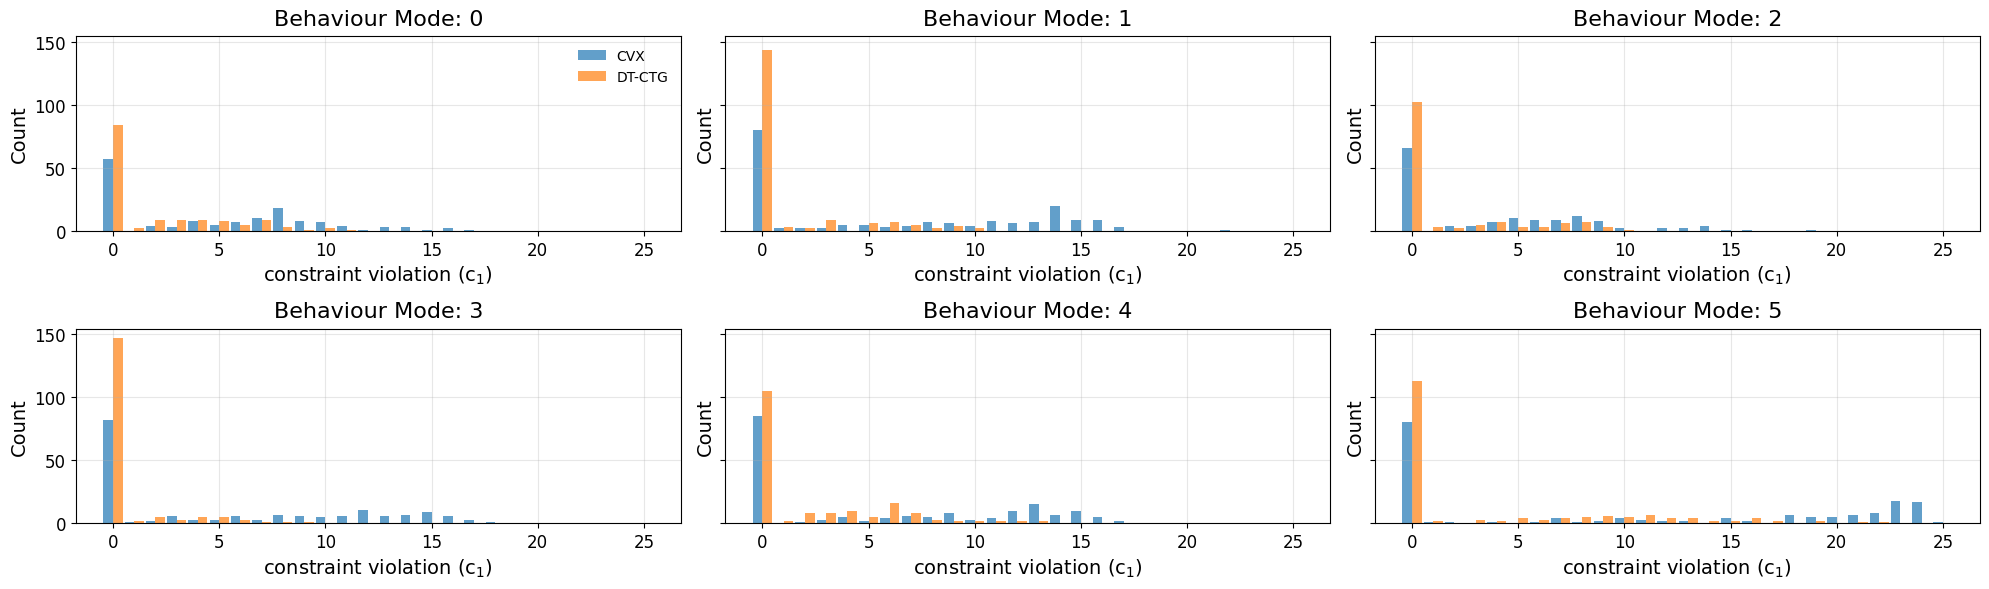

In [13]:

states_ws_DT_ctg  = data.get("states_ws_DT_ctg", None)
inflated = (obs['radius'] + robot_radius) * ff.safety_margin
# compute the ctg_00 for DT warmstart
ctgs0_dt_ctg  = _compute_ctg0_from_states(states_ws_DT_ctg, obs['position'], inflated) if states_ws_DT_ctg is not None else None
ctgs0_cvx     = data.get("ctgs0_cvx", None)
behavior      = np.asarray(data["behavior"]).reshape(-1)  # shape (N,)

count_ctg0_zero_per_behavior(behavior, ctgs0_cvx, ctgs0_dt_ctg, n_behaviors=6)

if ctgs0_dt_ctg is None or ctgs0_cvx is None:
    raise ValueError("One of the ctg arrays is None. Check inputs.")

# Flatten arrays
vals_dt  = np.array(ctgs0_dt_ctg).flatten()
vals_cvx = np.array(ctgs0_cvx).flatten()

if not (len(vals_dt) == len(vals_cvx) == len(behavior)):
    raise ValueError(f"Length mismatch: ctg_dt={len(vals_dt)}, ctg_cvx={len(vals_cvx)}, behavior={len(behavior)}")

# Optional: behavior names (in your usual order)
CASE_NAMES = [
    "left_fast",   # 0
    "left_slow",   # 1
    "right_fast",  # 2
    "right_slow",  # 3
    "direct_fast", # 4
    "direct_slow"  # 5
]

# -------------------------
# Global bins for all modes
# -------------------------
all_vals = np.concatenate([vals_dt, vals_cvx])
vmin, vmax = int(min(list(all_vals))), int(max(list(all_vals)))
bins = np.arange(vmin - 0.5, vmax + 1.5, 1)  # integer bins
bin_centers = (bins[:-1] + bins[1:]) / 2

bar_width = 0.45
offset    = bar_width / 2

# -------------------------
# Fonts
# -------------------------
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 14
TICK_FONTSIZE  = 12


# -------------------------
# Create 6 subplots
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 6), sharey=True)
axes = axes.ravel()

for mode in range(6):
    ax = axes[mode]
    mask = (behavior == mode)

    vals_dt_mode  = vals_dt[mask]
    vals_cvx_mode = vals_cvx[mask]

    # Hist counts for this mode
    hist_dt,  _ = np.histogram(vals_dt_mode,  bins=bins)
    hist_cvx, _ = np.histogram(vals_cvx_mode, bins=bins)

    # CVX bars (left in each bin)
    ax.bar(bin_centers - offset, hist_cvx, width=bar_width, label='CVX' if mode == 0 else None, alpha=0.7, color='tab:blue')
    
    # DT-CTG bars (right in each bin)
    ax.bar(bin_centers + offset, hist_dt, width=bar_width, label='DT-CTG' if mode == 0 else None, alpha=0.7, color='tab:orange')

    # ---- Fonts + layout ----
    ax.set_title(f"Behaviour Mode: {mode}", fontsize=TITLE_FONTSIZE, pad=8)

    ax.set_xticks(np.arange(vmin, vmax + 1, 5))
    ax.set_xticklabels(np.arange(vmin, vmax + 1, 5), fontsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    ax.set_xlabel("constraint violation (c$_{1}$)", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Count", fontsize=LABEL_FONTSIZE)
    ax.grid(True, alpha=0.3)
    if mode == 0:
        ax.legend(frameon=False)

#
# fig.suptitle("CTGS0 Violation Distributions by Behavior Mode", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Behavior 0: 142 samples, safe ratio: ART=0.592, CVX=0.401
Behavior 1: 183 samples, safe ratio: ART=0.781, CVX=0.437
Behavior 2: 142 samples, safe ratio: ART=0.718, CVX=0.465
Behavior 3: 173 samples, safe ratio: ART=0.850, CVX=0.474
Behavior 4: 175 samples, safe ratio: ART=0.600, CVX=0.486
Behavior 5: 176 samples, safe ratio: ART=0.642, CVX=0.455


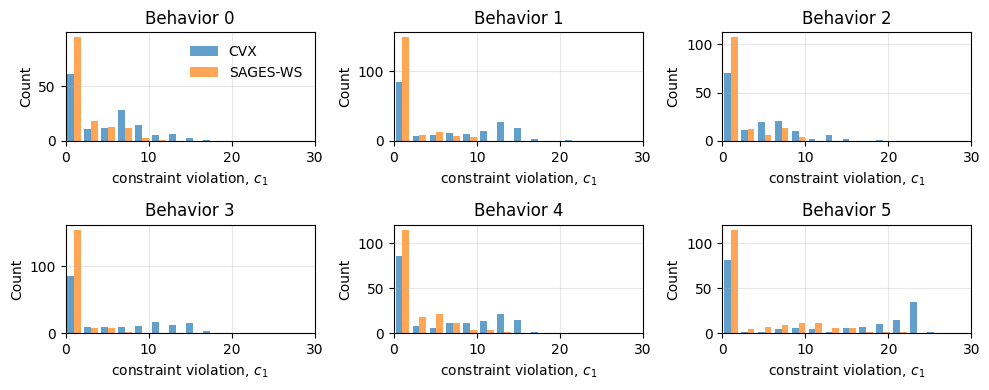

In [17]:
def plot_ctg_histogram(
    ctgs0_art,
    ctgs0_cvx,
    behav,
    n_time = 100,
    N_behavior=6,
): 
    # check the CTG 

    fig = plt.figure(figsize=(10, 4))
    bins = np.linspace(0, n_time, int(n_time/2)) # constraint violation bins
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    width = (bins[1] - bins[0]) * 0.4  # each pillar width

    for i in range(N_behavior):
        ctgs0_art_i = ctgs0_art[behav == i]
        ctgs0_cvx_i = ctgs0_cvx[behav == i]

        hist_DT, _ = np.histogram(ctgs0_art_i, bins=bins)
        hist_cvx, _ = np.histogram(ctgs0_cvx_i, bins=bins)
        
        ax_i = fig.add_subplot(2, 3, i + 1)
        ax_i.bar(bin_centers - width/2, hist_cvx, width=width, label="CVX", alpha=0.7)
        ax_i.bar(bin_centers + width/2, hist_DT, width=width, label="SAGES-WS", alpha=0.7)
        
        ax_i.set_xlabel("constraint violation, $c_1$")
        ax_i.set_ylabel("Count")
        ax_i.set_title(f"Behavior {i}")
        ax_i.grid(True, alpha=0.3)
        if i == 0:
            ax_i.legend(frameon=False)

        ax_i.set_xlim([0, 30])
        # ax_i.set_ylim([0, 75])

        print(f"Behavior {i}: {np.sum(behav==i)} samples, safe ratio: ART={np.sum(ctgs0_art_i==0)/len(ctgs0_art_i):.3f}, CVX={np.sum(ctgs0_cvx_i==0)/len(ctgs0_cvx_i):.3f}")

    fig.tight_layout()
    plt.show()

plot_ctg_histogram(ctgs0_dt_ctg, ctgs0_cvx, behavior)

# Warmstart Feasibility

In [18]:
behavior           = data["behavior"]          
i_unfeas_cvx       = data["i_unfeas_cvx"]  
i_unfeas_scp_cvx   = data["i_unfeas_scp_cvx"]  # 1D array of indices
i_unfeas_DT_ctg    = data["i_unfeas_DT_ctg"]


N = len(behavior)

def to_mask(idx, N):
    """Safe boolean mask from index list/array/None."""
    m = np.zeros(N, dtype=bool)
    if idx is None:
        return m
    arr = np.asarray(idx).ravel()
    if arr.size:
        arr = arr.astype(int)
        arr = arr[(arr >= 0) & (arr < N)]
        m[arr] = True
    return m

m_unfs_cvx       = to_mask(i_unfeas_cvx,       N)
m_unfs_scp_cvx   = to_mask(i_unfeas_scp_cvx,   N)
m_unfs_scp_dt    = to_mask(i_unfeas_DT_ctg,    N)

ev_cvx_fail = m_unfs_cvx 
ev_cvx_scp_fail = (~m_unfs_cvx) & m_unfs_scp_cvx # CVX WORKED BUT FAILED AT SCP PART
ev_dt_scp_fail = m_unfs_scp_dt # DT FALIED
dt_success_where_cvx_fails = (ev_cvx_fail | ev_cvx_scp_fail) & (~ev_dt_scp_fail)
unique_b = np.unique(behavior)

stats = {}

for b in unique_b:
    idx = np.where(behavior == b)[0]
    total_b = len(idx)

    if total_b == 0:
        continue

    # counts for each event
    count_cvx_fail        = np.sum(ev_cvx_fail[idx])
    count_cvx_scp_fail    = np.sum(ev_cvx_scp_fail[idx])
    count_dt_scp_fail     = np.sum(ev_dt_scp_fail[idx])
    count_dt_success_when_cvx_fails = np.sum(dt_success_where_cvx_fails[idx])

    stats[b] = {
        "total": total_b,
        "cvx_fail": count_cvx_fail,
        "cvx_fail_%": 100 * count_cvx_fail / total_b,

        "cvx_scp_fail": count_cvx_scp_fail,
        "cvx_scp_fail_%": 100 * count_cvx_scp_fail / total_b,

        "dt_scp_fail": count_dt_scp_fail,
        "dt_scp_fail_%": 100 * count_dt_scp_fail / total_b,

        "dt_success_where_cvx_fails": count_dt_success_when_cvx_fails,
        "dt_success_where_cvx_fails_%": 100 * count_dt_success_when_cvx_fails / total_b,
    }
print("\n=== Feasibility Comparison Per Behavior Mode ===")
for b in unique_b:
    r = stats[b]
    print(f"\nBehavior {b} (total={r['total']}):")
    print(f"  • CVX warm-start fails:          {r['cvx_fail']:3d}  ({r['cvx_fail_%']:.1f}%)")
    print(f"  • CVX-SCP refinement fails:      {r['cvx_scp_fail']:3d}  ({r['cvx_scp_fail_%']:.1f}%)")
    print(f"  • DT-SCP refinement fails:       {r['dt_scp_fail']:3d}  ({r['dt_scp_fail_%']:.1f}%)")
    print(f"  • DT succeeds where CVX fails:   {r['dt_success_where_cvx_fails']:3d}  ({r['dt_success_where_cvx_fails_%']:.1f}%)")



=== Feasibility Comparison Per Behavior Mode ===

Behavior 0.0 (total=142):
  • CVX warm-start fails:            1  (0.7%)
  • CVX-SCP refinement fails:        6  (4.2%)
  • DT-SCP refinement fails:         1  (0.7%)
  • DT succeeds where CVX fails:     6  (4.2%)

Behavior 1.0 (total=183):
  • CVX warm-start fails:            0  (0.0%)
  • CVX-SCP refinement fails:        7  (3.8%)
  • DT-SCP refinement fails:         1  (0.5%)
  • DT succeeds where CVX fails:     7  (3.8%)

Behavior 2.0 (total=142):
  • CVX warm-start fails:            2  (1.4%)
  • CVX-SCP refinement fails:        4  (2.8%)
  • DT-SCP refinement fails:         0  (0.0%)
  • DT succeeds where CVX fails:     6  (4.2%)

Behavior 3.0 (total=173):
  • CVX warm-start fails:            0  (0.0%)
  • CVX-SCP refinement fails:        6  (3.5%)
  • DT-SCP refinement fails:         0  (0.0%)
  • DT succeeds where CVX fails:     6  (3.5%)

Behavior 4.0 (total=175):
  • CVX warm-start fails:            3  (1.7%)
  • CVX-SCP refi

# SCP-Convergence
this is with respect to denominator N total

In [19]:
behavior_           = raw["behavior"]          # shape (1000,)
i_unfeas_scp_cvx_   = raw["i_unfeas_scp_cvx"]  # 1D array of indices
i_unfeas_DT_ctg_    = raw["i_unfeas_DT_ctg"]
i_unfeas_DT_ctg_op_    = raw["i_unfeas_DT_ctg_op"]

unique_b, counts_b = np.unique(behavior, return_counts=True)
print(dict(zip(unique_b, counts_b)))

def infeasibility_fraction(behavior, infeas_idx, label):
    total = {b: (behavior == b).sum() for b in np.unique(behavior)}
    infeas = {b: np.isin(np.where(behavior == b)[0], infeas_idx).sum() for b in total.keys()}
    frac = {b: infeas[b] / total[b] * 100.0 for b in total.keys()}
    print(f"\n--- {label} ---")
    for b in sorted(total.keys()):
        print(f"Behavior {b}: {infeas[b]:3d}/{total[b]:3d}  →  {100- frac[b]:6.2f}% feasible or {frac[b]:6.2f}% infeasible,")
    return infeas, frac

inf_cvx, frac_cvx = infeasibility_fraction(behavior_, i_unfeas_scp_cvx_, "Cvx+SCP infeasible")
inf_ctg, frac_ctg = infeasibility_fraction(behavior_, i_unfeas_DT_ctg_, "DT-CTG SCP infeasible")
inf_ctg_op, frac_ctg_op = infeasibility_fraction(behavior_, i_unfeas_DT_ctg_op_, "DT-CTG-OP SCP infeasible")


{0.0: 142, 1.0: 183, 2.0: 142, 3.0: 173, 4.0: 175, 5.0: 176}

--- Cvx+SCP infeasible ---
Behavior 0.0:   9/146  →   93.84% feasible or   6.16% infeasible,
Behavior 1.0:   6/183  →   96.72% feasible or   3.28% infeasible,
Behavior 2.0:   8/147  →   94.56% feasible or   5.44% infeasible,
Behavior 3.0:   0/173  →  100.00% feasible or   0.00% infeasible,
Behavior 4.0:   7/175  →   96.00% feasible or   4.00% infeasible,
Behavior 5.0:   8/176  →   95.45% feasible or   4.55% infeasible,

--- DT-CTG SCP infeasible ---
Behavior 0.0:   1/146  →   99.32% feasible or   0.68% infeasible,
Behavior 1.0:   0/183  →  100.00% feasible or   0.00% infeasible,
Behavior 2.0:   2/147  →   98.64% feasible or   1.36% infeasible,
Behavior 3.0:   0/173  →  100.00% feasible or   0.00% infeasible,
Behavior 4.0:   2/175  →   98.86% feasible or   1.14% infeasible,
Behavior 5.0:   0/176  →  100.00% feasible or   0.00% infeasible,

--- DT-CTG-OP SCP infeasible ---
Behavior 0.0:   1/146  →   99.32% feasible or   0.68% 

# Semantic Correctness

In [20]:

# =========================
# CONFIG / HYPERPARAMETERS
# =========================

# Fast vs slow: step index thresholds (0-based indices)
FAST_MAX_STEP  = 75      # fast if first hit <= this
SLOW_MIN_STEP  = 76      # slow if first hit >= this

# How close to goal to count as "arrived"
GOAL_POS_TOL   = 0.06    # in meters, on (x, y); tune if needed
USE_FULL_STATE_NORM = False  # True -> use ||(x,y,vx,vy,...)||; False -> only (x,y)

# Geometry for left/right corridor region (mirrors build_waypoint_for_obstacle)
HALF_ANGLE_DEG     = 32.0
NEAR_MARGIN_MIN    = 0.04
NEAR_MARGIN_MAX    = 0.10
THRE = 0.06

# Which state sources from the npz to evaluate (if present)
PREFERRED_STATE_KEYS = [
    # warmstrt soln
    "states_cvx",
    "states_ws_DT_ctg",
    # scp solution
    "states_scp_DT_ctg",
    "states_scp_DT_ctg_op",
    "states_scp_cvx",
]



# Try to locate a behavior-mode array
# behavior_key_candidates = [k for k in data.files if "behav" in k.lower() or "mode" in k.lower()]
behavior_key_candidates = [k for k in data.keys()
                           if "behav" in k.lower() or "mode" in k.lower()]
if not behavior_key_candidates:
    raise KeyError(
        "Could not find a behavior-mode array in the npz. "
        "Please add/rename an array like 'behavior_modes' or 'modes'."
    )

BEHAVIOR_KEY = behavior_key_candidates[0]
# behavior_modes = np.asarray(data[BEHAVIOR_KEY]).astype(int).ravel()
# print(f"Using behavior modes from key: {BEHAVIOR_KEY}, shape={behavior_modes.shape}")
behavior_modes = np.asarray(data[BEHAVIOR_KEY]).astype(int).ravel()
print(f"Using behavior modes from key: {BEHAVIOR_KEY}, shape={behavior_modes.shape}")

# Collect which state arrays we will evaluate
state_sources = {}
# for k in PREFERRED_STATE_KEYS:
#     if k in data.files:
#         state_sources[k] = data[k]


for k in PREFERRED_STATE_KEYS:
    if k in data.keys():
        state_sources[k] = data[k]

if not state_sources:
    raise KeyError(
        "No known 'states_*' arrays found among PREFERRED_STATE_KEYS.\n"
        f"Present state-like keys: {[k for k in data.files if k.startswith('states_')]}"
    )

print("Evaluating semantic correctness for state sources:")
for k, v in state_sources.items():
    print(f"  - {k}: shape={v.shape}")

# =========================
# GEOMETRY HELPERS
# =========================

N_STATE = ff.N_STATE  # should be 6

# Obstacles / geometry from ff_scenario
c_all   = np.asarray(ff.obs["position"])   # shape (3, 2)
r_all   = np.asarray(ff.obs["radius"])     # shape (3,)
robot_r = float(ff.robot_radius)
gamma   = float(ff.safety_margin)
table_lo = np.asarray(ff.table["xy_low"])
table_hi = np.asarray(ff.table["xy_up"])

# Left / middle / right indices (assumed from your comment / function)
BODY_LEFT  = 0
BODY_MID   = 1
BODY_RIGHT = 2

inflated_all = (r_all + robot_r) * gamma

def wrap_to_pi(angle):
    """Wrap angle to [-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi

def get_target_state():
    """Midpoint of goal region + zero velocities (as you used in previous code)."""
    return np.array([(ff.goal_region['xy_low'][0] + ff.goal_region['xy_up'][0])/2,
                    (ff.goal_region['xy_low'][1] + ff.goal_region['xy_up'][1])/2,
                    0.0,
                    0.0,
                    0.0,
                    0.0])

TARGET_STATE = get_target_state()

def extract_traj_TxS(states_array, idx):
    """
    Extract trajectory i as shape (T, N_STATE).
    Supports arrays shaped:
      (N, N_STATE, T)  or (N, T, N_STATE)
    """
    traj = np.asarray(states_array[idx])
    if traj.ndim != 2:
        raise ValueError(f"Expected per-trajectory array to be 2D, got {traj.shape}")
    if traj.shape[0] == N_STATE and traj.shape[1] != N_STATE:
        # (N_STATE, T) -> transpose
        return traj.T
    elif traj.shape[1] == N_STATE and traj.shape[0] != N_STATE:
        # (T, N_STATE)
        return traj
    else:
        raise ValueError(
            f"Cannot infer time/state axes from shape {traj.shape}. "
            f"Expected one axis to be N_STATE={N_STATE}."
        )

def passes_corridor_sector(x, y, body_idx):
    """
    Check whether (x(t),y(t)) ever passes through the (deterministic) annular sector
    used conceptually by build_waypoint_for_obstacle for the given body (left/right).
    """
    c_body = c_all[body_idx]
    r_body = float(r_all[body_idx])
    c_mid  = c_all[BODY_MID]

    # sector center direction (body -> middle)
    v_bm = c_mid - c_body
    base_theta = np.arctan2(v_bm[1], v_bm[0])
    half_angle = np.deg2rad(HALF_ANGLE_DEG)

    R_inflated_body = (r_body + robot_r) * gamma
    R_min = R_inflated_body + NEAR_MARGIN_MIN - THRE
    R_max = R_inflated_body + NEAR_MARGIN_MAX + THRE

    for xt, yt in zip(x, y):
        p = np.array([xt, yt], dtype=float)

        # Optional: restrict to table with padding
        pad_lo = table_lo + robot_r
        pad_hi = table_hi - robot_r
        if not (pad_lo[0] <= p[0] <= pad_hi[0] and pad_lo[1] <= p[1] <= pad_hi[1]):
            continue

        rel = p - c_body
        r   = np.linalg.norm(rel)
        if r == 0.0:
            continue

        theta = np.arctan2(rel[1], rel[0])
        dtheta = wrap_to_pi(theta - base_theta)

        if abs(dtheta) <= half_angle and (R_min <= r <= R_max):
            return True

    return False

def first_goal_hit_time(traj_TxS):
    """
    Return (t_hit, hit_bool) where t_hit is the first time index where distance
    to TARGET_STATE is within GOAL_POS_TOL (or full-state tolerance).
    If never hit, returns (None, False).
    """
    if USE_FULL_STATE_NORM:
        diff = traj_TxS - TARGET_STATE[None, :]
        d = np.linalg.norm(diff, axis=1)
    else:
        # only (x,y)
        diff_xy = traj_TxS[:, :2] - TARGET_STATE[None, :2,]
        d = np.linalg.norm(diff_xy, axis=1)

    hits = np.where(d <= GOAL_POS_TOL)[0]
    if len(hits) == 0:
        return 99, True
    return int(hits[0]), True

def check_semantics_for_traj(traj_TxS, behavior_mode):
    """
    Given one trajectory (T, N_STATE) and a behavior_mode in {0..5},
    return a dict with semantic checks and an overall 'ok' flag.
    """
    # Positions
    x = traj_TxS[:, 0]
    y = traj_TxS[:, 1]

    left_pass  = passes_corridor_sector(x, y, BODY_LEFT)
    right_pass = passes_corridor_sector(x, y, BODY_RIGHT)

    t_hit, hit_goal = first_goal_hit_time(traj_TxS)

    # Corridors vs direct semantics
    want_left  = behavior_mode in {0, 1}
    want_right = behavior_mode in {2, 3}
    want_direct = behavior_mode in {4, 5}

    is_direct = (not left_pass) and (not right_pass)

    corridor_ok = True
    if want_left:
        corridor_ok = left_pass and not right_pass
    elif want_right:
        corridor_ok = right_pass and not left_pass
    else:
        corridor_ok = True

    # Fast vs slow semantics
    fast_modes = {0, 2, 4}
    slow_modes = {1, 3, 5}

    fast_slow_ok = True
    if behavior_mode in fast_modes:
        fast_slow_ok = hit_goal and (t_hit is not None) and (t_hit <= FAST_MAX_STEP)
    elif behavior_mode in slow_modes:
        fast_slow_ok = hit_goal and (t_hit is not None) and (t_hit >= SLOW_MIN_STEP)

    overall_ok = corridor_ok and fast_slow_ok

    return {
        "corridor_ok": corridor_ok,
        "fast_slow_ok": fast_slow_ok,
        "hit_goal": hit_goal,
        "t_hit": t_hit,
        "left_pass": left_pass,
        "right_pass": right_pass,
        "is_direct": is_direct,
        "overall_ok": overall_ok,
    }

# =========================
# MAIN EVAL LOOP
# =========================

def evaluate_source(states_array, behavior_modes, source_name):
    states_array = np.asarray(states_array)
    n_traj = states_array.shape[0]
    if n_traj != behavior_modes.shape[0]:
        raise ValueError(
            f"Mismatch between #traj in {source_name} ({n_traj}) "
            f"and behavior_modes ({behavior_modes.shape[0]})."
        )

    stats = {
        "total": defaultdict(int),
        "overall_ok": defaultdict(int),
        "corridor_ok": defaultdict(int),
        "fast_slow_ok": defaultdict(int),
        "hit_goal": defaultdict(int),
    }

    for i in range(n_traj):
        mode = int(behavior_modes[i])
        traj = extract_traj_TxS(states_array, i)
        res  = check_semantics_for_traj(traj, mode)

        stats["total"][mode] += 1
        if res["overall_ok"]:
            stats["overall_ok"][mode] += 1
        if res["corridor_ok"]:
            stats["corridor_ok"][mode] += 1
        if res["fast_slow_ok"]:
            stats["fast_slow_ok"][mode] += 1
        if res["hit_goal"]:
            stats["hit_goal"][mode] += 1

    # Pretty print
    print(f"\n===== Semantic stats for {source_name} =====")
    print(f"FAST_MAX_STEP={FAST_MAX_STEP}, SLOW_MIN_STEP={SLOW_MIN_STEP}, "
          f"GOAL_POS_TOL={GOAL_POS_TOL}, USE_FULL_STATE_NORM={USE_FULL_STATE_NORM}")
    header = ("mode", "total", "overall_ok", "overall_%", "corridor_%", "fast/slow_%", "hit_goal_%")
    print("{:>4s} | {:>5s} | {:>10s} | {:>10s} | {:>11s} | {:>11s} | {:>10s}".format(*header))
    print("-" * 72)
    for mode in range(6):
        tot = stats["total"][mode]
        if tot == 0:
            print(f"{mode:4d} | {0:5d} | {0:10d} | {'-':>10s} | {'-':>11s} | {'-':>11s} | {'-':>10s}")
            continue
        o = stats["overall_ok"][mode]
        c = stats["corridor_ok"][mode]
        f = stats["fast_slow_ok"][mode]
        h = stats["hit_goal"][mode]

        def pct(k): return 100.0 * k / tot
        print(f"{mode:4d} | {tot:5d} | {o:10d} | {pct(o):10.1f} | {pct(c):11.1f} | {pct(f):11.1f} | {pct(h):10.1f}")

    return stats

# Run evaluation for each state source
all_stats = {}
for name, arr in state_sources.items():
    all_stats[name] = evaluate_source(arr, behavior_modes, name)


Using behavior modes from key: behavior, shape=(991,)
Evaluating semantic correctness for state sources:
  - states_cvx: shape=(991, 6, 101)
  - states_ws_DT_ctg: shape=(991, 6, 101)
  - states_scp_DT_ctg: shape=(991, 6, 101)
  - states_scp_DT_ctg_op: shape=(991, 6, 101)
  - states_scp_cvx: shape=(991, 6, 101)

===== Semantic stats for states_cvx =====
FAST_MAX_STEP=75, SLOW_MIN_STEP=76, GOAL_POS_TOL=0.06, USE_FULL_STATE_NORM=False
mode | total | overall_ok |  overall_% |  corridor_% | fast/slow_% | hit_goal_%
------------------------------------------------------------------------
   0 |   142 |        142 |      100.0 |       100.0 |       100.0 |      100.0
   1 |   183 |        183 |      100.0 |       100.0 |       100.0 |      100.0
   2 |   142 |        142 |      100.0 |       100.0 |       100.0 |      100.0
   3 |   173 |        173 |      100.0 |       100.0 |       100.0 |      100.0
   4 |   175 |        175 |      100.0 |       100.0 |       100.0 |      100.0
   5 |   17